# Pendulum Quadrature, Mercury Precession, and N-Body Orbits

Numerical quadrature of the pendulum period, orbital integration error, Mercury perihelion precession, and Earth–Moon dynamics.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


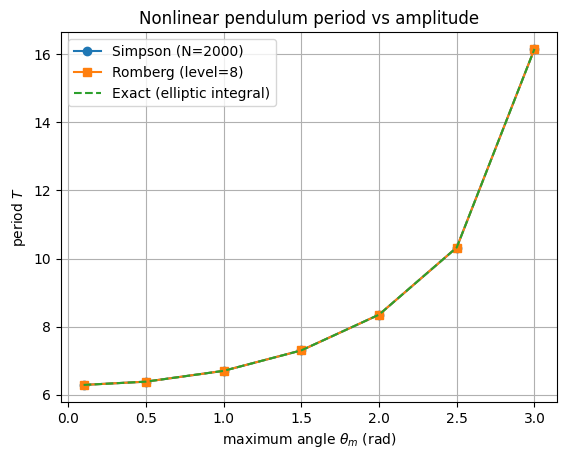

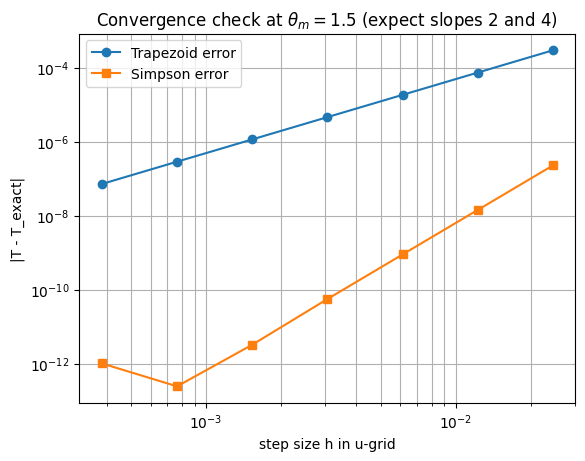

theta_m (rad) | T_simpson(N=2000) | T_romberg(level=8) | T_exact
   0.100 |     6.2871145493 |       6.2871145493 | 6.2871145493
   0.500 |     6.3827896977 |       6.3827896977 | 6.3827896977
   1.000 |     6.6999756644 |       6.6999756644 | 6.6999756644
   1.500 |     7.3008649421 |       7.3008649421 | 7.3008649421
   2.000 |     8.3497529269 |       8.3497529269 | 8.3497529269
   2.500 |    10.3231628659 |      10.3231628659 | 10.3231628659
   3.000 |    16.1555393724 |      16.1555393724 | 16.1555393724


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

try:
    import mpmath as mp
    HAVE_MPMATH = True
except ImportError:
    HAVE_MPMATH = False


def I_theta_m_numeric(theta_m, method = "simpson", N = 2000, romberg_level = 6):
    umax = math.sqrt(theta_m);

    def f_u(u):
        # integrand in u after substitution θ = θ_m - u^2
        # handle u=0 by its finite limit to avoid 0/0 roundoff
        if u == 0.0:
            return 2.0 / math.sqrt(math.sin(theta_m));
        theta = theta_m - u*u
        return 2.0*u / math.sqrt(math.cos(theta) - math.cos(theta_m));

    def composite_trap(a, b, n):
        x = np.linspace(a, b, n + 1);
        y = np.array([f_u(xi) for xi in x], dtype = float);
        h = (b - a) / n;
        return h * (0.5*y[0] + y[1:-1].sum() + 0.5*y[-1]);

    def composite_simpson(a, b, n):
        if n % 2 == 1:
            n += 1;
        h = (b - a) / n;
        x = np.linspace(a, b, n + 1);
        y = np.array([f_u(xi) for xi in x], dtype = float);
        return (h/3.0) * (y[0] + y[-1] + 4.0*y[1:-1:2].sum() + 2.0*y[2:-1:2].sum());


    def romberg(a, b, levels):
        R = np.zeros((levels, levels), dtype = float);
        for i in range(levels):
            n = 2**i;
            R[i, 0] = composite_trap(a, b, n);
            for k in range(1, i + 1):
                R[i, k] = R[i, k-1] + (R[i, k-1] - R[i-1, k-1]) / (4**k - 1);
        return R;

    if method == "trap":
        return composite_trap(0.0, umax, N)
    elif method == "simpson":
        return composite_simpson(0.0, umax, N)
    elif method == "romberg":
        R = romberg(0.0, umax, romberg_level)
        return R[romberg_level - 1, romberg_level - 1]
    else:
        raise ValueError("method must be 'trap', 'simpson', or 'romberg'")

def period_T(theta_m, method = "simpson", N = 2000, romberg_level = 6):

    I = I_theta_m_numeric(theta_m, method = method, N = N, romberg_level = romberg_level);
    return (4.0 / math.sqrt(2.0)) * I;

def T_exact(theta_m):
    if not HAVE_MPMATH:
        return None;
    k = math.sin(theta_m / 2.0);
    return float(4.0 * mp.ellipk(k*k));  # mpmath uses parameter m = k^2


# ----------------------------
# Run for several amplitudes
# ----------------------------
theta_list = [0.1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

# Choose a solid default accuracy:
# Simpson with N=2000 is typically extremely accurate here.
T_simp = np.array([period_T(th, method="simpson", N=2000) for th in theta_list])

# Romberg: for large amplitudes near π, increase level a bit.
T_romb = np.array([period_T(th, method="romberg", romberg_level=8) for th in theta_list])

# Exact benchmark (if available)
if HAVE_MPMATH:
    T_ex = np.array([T_exact(th) for th in theta_list])
else:
    T_ex = None

# ----------------------------
# Plot 1: Period vs amplitude
# ----------------------------
plt.figure()
plt.plot(theta_list, T_simp, marker='o', label="Simpson (N=2000)")
plt.plot(theta_list, T_romb, marker='s', label="Romberg (level=8)")
if T_ex is not None:
    plt.plot(theta_list, T_ex, linestyle='--', label="Exact (elliptic integral)")
plt.xlabel(r"maximum angle $\theta_m$ (rad)")
plt.ylabel(r"period $T$")
plt.title("Nonlinear pendulum period vs amplitude")
plt.grid(True)
plt.legend()
plt.show()

# ----------------------------
# Adequacy check: convergence + error order (pick one theta_m)
# ----------------------------
theta_test = 1.5
Tex = T_exact(theta_test) if HAVE_MPMATH else None

Ns = np.array([50, 100, 200, 400, 800, 1600, 3200])
umax = math.sqrt(theta_test)
hs = umax / Ns

T_trap = np.array([period_T(theta_test, method="trap", N=int(n)) for n in Ns])
T_s = np.array([period_T(theta_test, method="simpson", N=int(n)) for n in Ns])

plt.figure()
if Tex is not None:
    err_trap = np.abs(T_trap - Tex)
    err_simp = np.abs(T_s - Tex)
    plt.loglog(hs, err_trap, marker='o', label="Trapezoid error")
    plt.loglog(hs, err_simp, marker='s', label="Simpson error")
    plt.xlabel("step size h in u-grid")
    plt.ylabel("|T - T_exact|")
    plt.title(r"Convergence check at $\theta_m=1.5$ (expect slopes 2 and 4)")
    plt.grid(True, which="both")
    plt.legend()
else:
    # If no exact benchmark, compare successive refinements as a practical adequacy test
    delta_trap = np.abs(T_trap[1:] - T_trap[:-1])
    delta_simp = np.abs(T_s[1:] - T_s[:-1])
    plt.loglog(hs[1:], delta_trap, marker='o', label="Trapezoid |ΔT| between refinements")
    plt.loglog(hs[1:], delta_simp, marker='s', label="Simpson |ΔT| between refinements")
    plt.xlabel("step size h in u-grid")
    plt.ylabel("refinement difference")
    plt.title(r"Adequacy via refinement differences at $\theta_m=1.5$")
    plt.grid(True, which="both")
    plt.legend()
plt.show()

# ----------------------------
# Print a small table
# ----------------------------
print("theta_m (rad) | T_simpson(N=2000) | T_romberg(level=8)" + (" | T_exact" if T_ex is not None else ""))
for i, th in enumerate(theta_list):
    if T_ex is not None:
        print(f"{th:8.3f} | {T_simp[i]:16.10f} | {T_romb[i]:18.10f} | {T_ex[i]:10.10f}")
    else:
        print(f"{th:8.3f} | {T_simp[i]:16.10f} | {T_romb[i]:18.10f}")


Earth (v0=2π) closure error after 1 yr:
dt      |  |r(1yr)-r(0)| (AU)   |  ΔE (end-start)   |  ΔL (end-start)
 0.001 |         0.00017570 |   2.56150656e-12 |   7.10542736e-15
 0.005 |         0.00439288 |   3.94316686e-08 |  -1.50990331e-14
 0.010 |         0.01757487 |   2.53841575e-06 |  -1.77635684e-15
 0.020 |         0.07033262 |   1.65376071e-04 |  -5.32907052e-15
 0.050 |         0.43713646 |   4.06716256e-02 |   1.77635684e-15


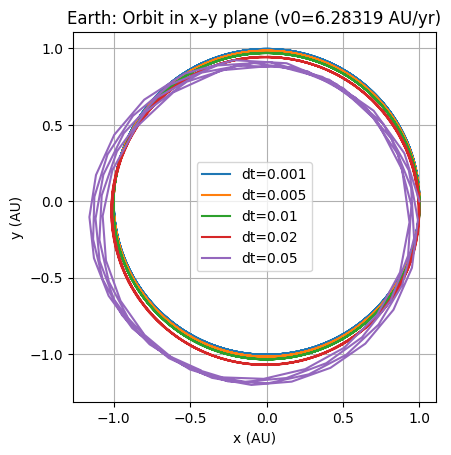

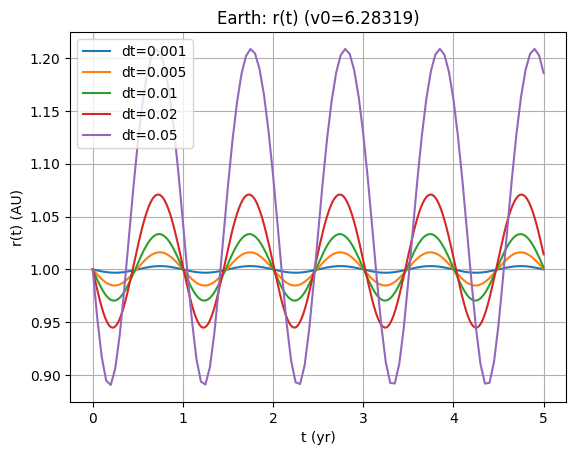

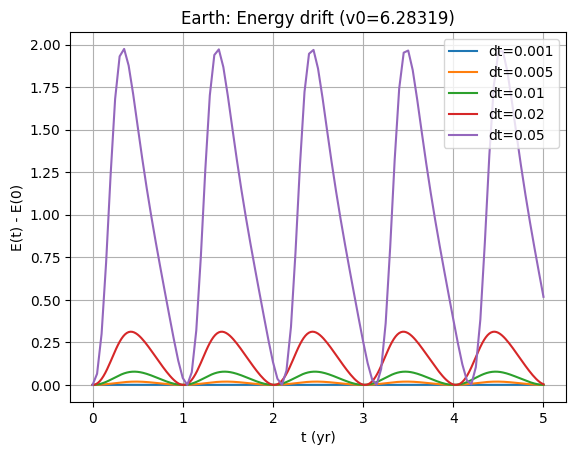

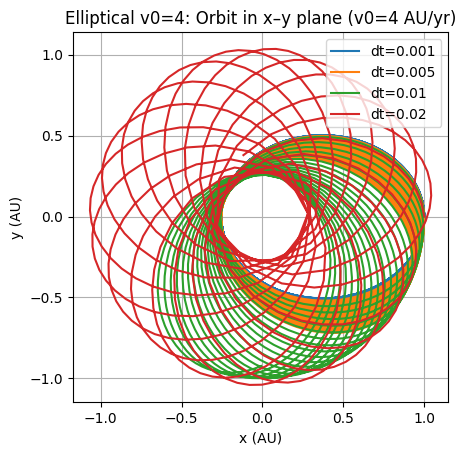

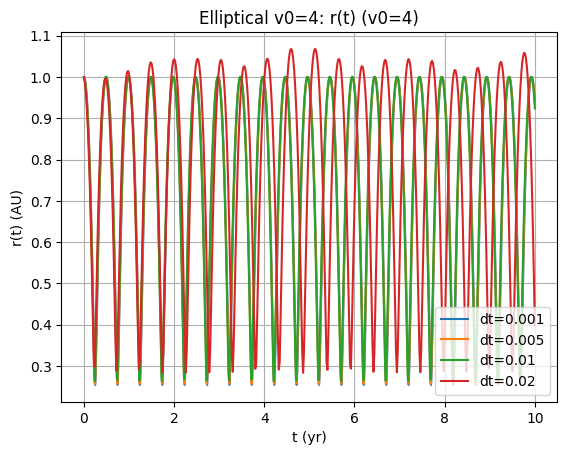

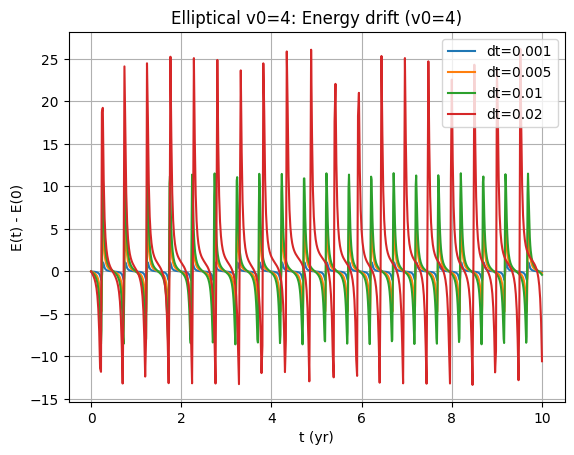

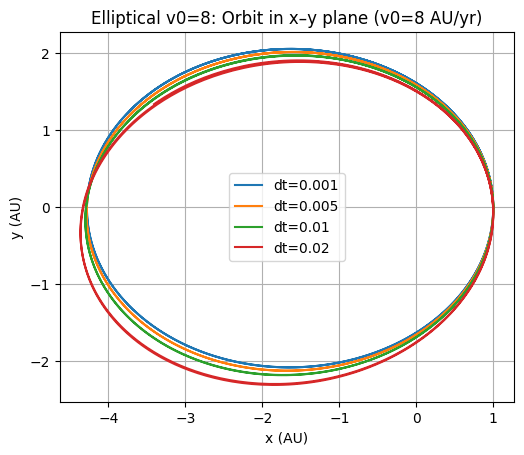

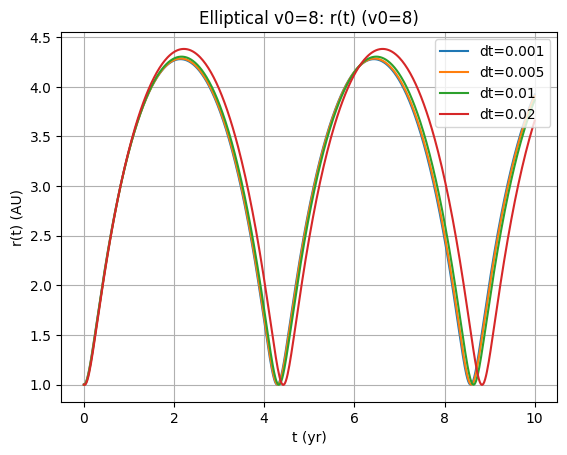

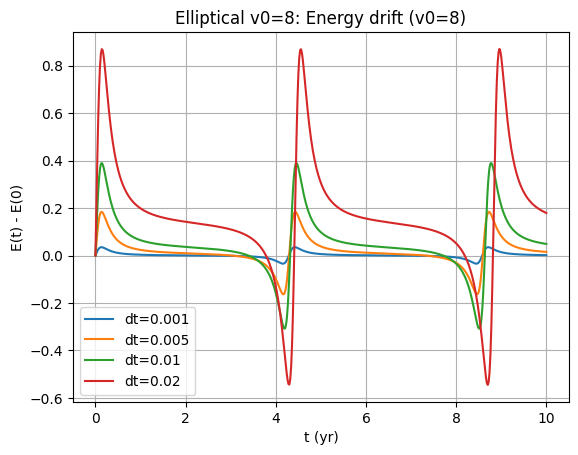

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

PI = np.pi
GM = 4.0 * PI**2   # AU^3 / yr^2  (Msun = 1)

def integrate_orbit(dt, Ttot = 10.0, r0 = 1.0, v0 = 2*PI, method = "cromer"):
    n = int(Ttot/dt) + 1;
    t = np.arange(n) * dt;
    x  = np.zeros(n); y  = np.zeros(n);
    vx = np.zeros(n); vy = np.zeros(n);
    x[0] = r0; y[0] = 0.0;
    vx[0] = 0.0; vy[0] = v0;

    for i in range(n-1):
        r = np.hypot(x[i], y[i]);
        ax = -GM * x[i] / r**3;
        ay = -GM * y[i] / r**3;

        # Euler–Cromer
        vx[i+1] = vx[i] + ax*dt;
        vy[i+1] = vy[i] + ay*dt;
        x[i+1] = x[i] + vx[i+1]*dt;
        y[i+1] = y[i] + vy[i+1]*dt;

    r = np.hypot(x, y);
    v2 = vx*vx + vy*vy;
    E = 0.5*v2 - GM/r;
    L = x*vy - y*vx;
    return t, x, y, r, E, L;

def closure_error_one_year(dt, v0 = 2*PI):
    t,x,y,r,E,L = integrate_orbit(dt, Ttot = 1.0, v0 = v0, method = "cromer");
    return np.hypot(x[-1]-x[0], y[-1]-y[0]), (E[-1]-E[0]), (L[-1]-L[0]);

def make_plots_for_v(v0, dt_list, Ttot=10.0, title_prefix=""):
    # --- Orbit plot
    plt.figure()
    for dt in dt_list:
        t,x,y,r,E,L = integrate_orbit(dt, Ttot=Ttot, v0=v0, method="cromer")
        plt.plot(x, y, label=f"dt={dt:g}")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("x (AU)")
    plt.ylabel("y (AU)")
    plt.title(f"{title_prefix} Orbit in x–y plane (v0={v0:g} AU/yr)")
    plt.grid(True)
    plt.legend()
    plt.show()

    # --- Radius vs time
    plt.figure()
    for dt in dt_list:
        t,x,y,r,E,L = integrate_orbit(dt, Ttot=Ttot, v0=v0, method="cromer")
        plt.plot(t, r, label=f"dt={dt:g}")
    plt.xlabel("t (yr)")
    plt.ylabel("r(t) (AU)")
    plt.title(f"{title_prefix} r(t) (v0={v0:g})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # --- Energy drift vs time
    plt.figure()
    for dt in dt_list:
        t,x,y,r,E,L = integrate_orbit(dt, Ttot=Ttot, v0=v0, method="cromer")
        plt.plot(t, E - E[0], label=f"dt={dt:g}")
    plt.xlabel("t (yr)")
    plt.ylabel("E(t) - E(0)")
    plt.title(f"{title_prefix} Energy drift (v0={v0:g})")
    plt.grid(True)
    plt.legend()
    plt.show()

# -----------------------------
# Part 1: Earth circular orbit sensitivity
# -----------------------------
dt_list_earth = [0.001, 0.005, 0.01, 0.02, 0.05]

print("Earth (v0=2π) closure error after 1 yr:")
print("dt      |  |r(1yr)-r(0)| (AU)   |  ΔE (end-start)   |  ΔL (end-start)")
for dt in dt_list_earth:
    cerr, dE, dL = closure_error_one_year(dt, v0=2*PI)
    print(f"{dt:6.3f} | {cerr:18.8f} | {dE:16.8e} | {dL:16.8e}")

make_plots_for_v(v0=2*PI, dt_list=dt_list_earth, Ttot=5.0, title_prefix="Earth:")

# -----------------------------
# Part 2: Other initial speeds (elliptical)
# -----------------------------
dt_list_ell = [0.001, 0.005, 0.01, 0.02]

make_plots_for_v(v0=4.0, dt_list=dt_list_ell, Ttot=10.0, title_prefix="Elliptical v0=4:")
make_plots_for_v(v0=8.0, dt_list=dt_list_ell, Ttot=10.0, title_prefix="Elliptical v0=8:")


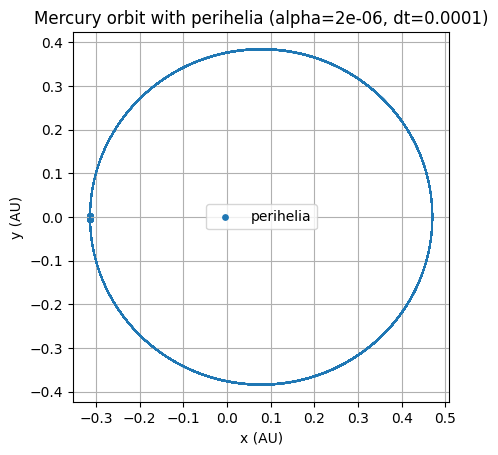

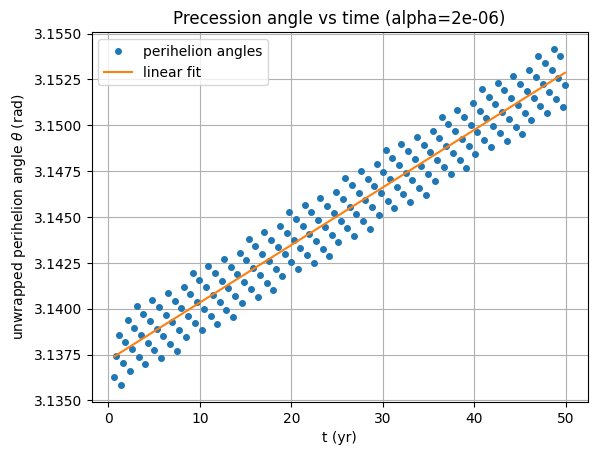

alpha values used: [0.e+00 1.e-06 2.e-06 5.e-06 1.e-05 2.e-05 5.e-05 1.e-04]
rates (deg/yr): [-0.00267531  0.00753153  0.01797987  0.04924246  0.10085072  0.20475641
  0.51630122  1.0363356 ]

Baseline numerical rate at alpha=0: -0.002675305310549002 deg/yr
Baseline-corrected slope m0 = 1.038718e+04 (deg/yr)/AU^2
Mercury GR precession: 1.142589e-04 deg/yr
=  41.133 arcsec/century


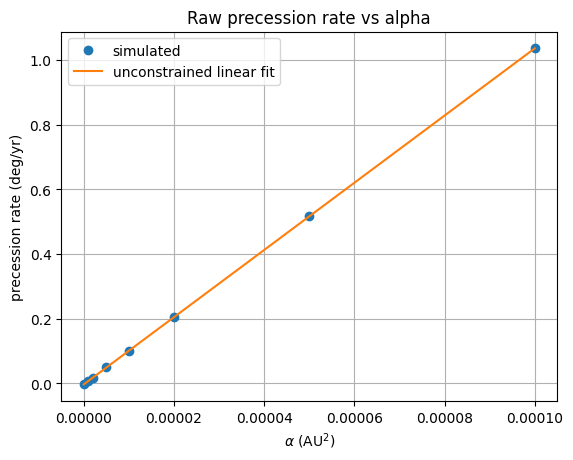

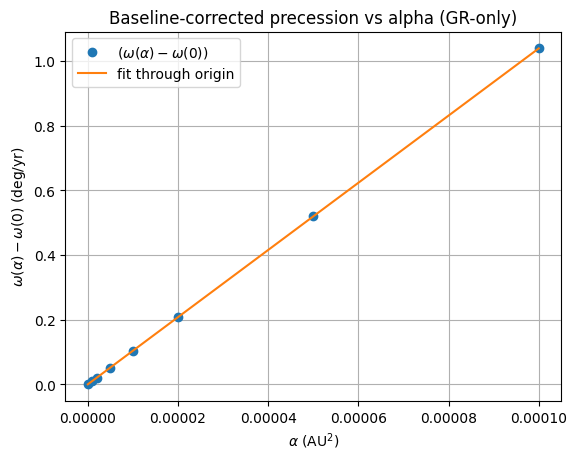

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

PI = np.pi
GM = 4.0 * PI**2  # AU^3 / yr^2

# Mercury initial conditions (perihelion start)
r_peri = 0.47;     # AU
v_peri = 8.2;      # AU/yr

# Mercury GR parameter (AU^2)
alpha_mercury = 1.1e-8;


def integrate_mercury(alpha = 0.0, dt = 1e-4, Ttot = 50.0):
    n = int(Ttot / dt) + 1;
    t = np.arange(n) * dt;
    x  = np.zeros(n); y  = np.zeros(n);
    vx = np.zeros(n); vy = np.zeros(n);

    # Start at perihelion on +x axis, tangential velocity +y
    x[0], y[0] = r_peri, 0.0;
    vx[0], vy[0] = 0.0, v_peri;

    for i in range(n - 1):
        r = np.hypot(x[i], y[i]);
        fac = -GM * (1.0 + alpha / (r * r)) / (r**3);
        ax = fac * x[i];
        ay = fac * y[i];

        # Euler–Cromer update
        vx[i+1] = vx[i] + ax * dt;
        vy[i+1] = vy[i] + ay * dt;
        x[i+1] = x[i] + vx[i+1] * dt;
        y[i+1] = y[i] + vy[i+1] * dt;

    r = np.hypot(x, y);
    return t, x, y, r;


def find_perihelia_indices(r):
    return np.where((r[1:-1] < r[:-2]) & (r[1:-1] < r[2:]))[0] + 1;


def precession_rate(alpha, dt = 1e-4, Ttot = 50.0, skip_first = 2, make_plots = False):
    t, x, y, r = integrate_mercury(alpha = alpha, dt = dt, Ttot = Ttot);
    i = find_perihelia_indices(r);

    if len(i) < (skip_first + 6):
        raise RuntimeError("Not enough perihelia found; increase Ttot or decrease dt.");

    i = i[skip_first:];
    tp = t[i];
    theta = np.arctan2(y[i], x[i]);
    theta = np.unwrap(theta);

    # Linear least squares fit: theta = omega t + b
    A = np.vstack([tp, np.ones_like(tp)]).T;
    omega, b = np.linalg.lstsq(A, theta, rcond = None)[0];

    rate_deg_per_yr = omega * (180.0 / np.pi);

    if make_plots:
        # Orbit + perihelia markers
        plt.figure();
        plt.plot(x, y, lw = 1);
        plt.scatter(x[idx], y[idx], s = 15, label = "perihelia")
        plt.gca().set_aspect("equal", adjustable="box")
        plt.xlabel("x (AU)"); plt.ylabel("y (AU)")
        plt.title(f"Mercury orbit with perihelia (alpha={alpha:g}, dt={dt:g})")
        plt.grid(True); plt.legend()
        plt.show()

        # theta(t) + fit
        plt.figure()
        plt.plot(tp, theta, "o", ms=4, label="perihelion angles")
        plt.plot(tp, omega*tp + b, label="linear fit")
        plt.xlabel("t (yr)")
        plt.ylabel(r"unwrapped perihelion angle $\theta$ (rad)")
        plt.title(f"Precession angle vs time (alpha={alpha:g})")
        plt.grid(True); plt.legend()
        plt.show()

    return rate_deg_per_yr


# -------------------------
# MAIN: rate vs alpha, baseline-correct, extrapolate
# -------------------------
dt = 1e-4
Ttot = 50.0

# Use small exaggerated alphas (near-linear regime)
alpha_list = np.array([0.0, 1e-6, 2e-6, 5e-6, 1e-5, 2e-5, 5e-5, 1e-4])

rates = []
for a in alpha_list:
    # Make diagnostic plots for one representative alpha (optional)
    make_plots = (a == 2e-6)
    rates.append(precession_rate(a, dt=dt, Ttot=Ttot, skip_first=2, make_plots=make_plots))
rates = np.array(rates)

print("alpha values used:", alpha_list)
print("rates (deg/yr):", rates)

# -------------------------
# BASELINE CORRECTION (THIS IS THE IMPORTANT FIX)
# -------------------------
rate0 = rates[0]                 # numerical precession at alpha=0 (artifact)
rates_corr = rates - rate0        # GR-only contribution relative to alpha=0

# Fit THROUGH ORIGIN: rates_corr ≈ m0 * alpha
# (This is the physically correct small-alpha behavior)
m0 = np.sum(alpha_list * rates_corr) / np.sum(alpha_list**2)

# Extrapolate to Mercury alpha
rate_mercury_deg_per_yr = m0 * alpha_mercury
rate_mercury_arcsec_per_cent = rate_mercury_deg_per_yr * 3600.0 * 100.0

print("\nBaseline numerical rate at alpha=0:", rate0, "deg/yr")
print("Baseline-corrected slope m0 =", f"{m0:.6e}", "(deg/yr)/AU^2")
print("Mercury GR precession:", f"{rate_mercury_deg_per_yr:.6e}", "deg/yr")
print("= ", f"{rate_mercury_arcsec_per_cent:.3f}", "arcsec/century")

# -------------------------
# Plot 1: raw rate vs alpha (shows small intercept artifact)
# -------------------------
m_raw, c_raw = np.polyfit(alpha_list, rates, 1)
aa = np.linspace(alpha_list.min(), alpha_list.max(), 200)

plt.figure()
plt.plot(alpha_list, rates, "o", label="simulated")
plt.plot(aa, m_raw*aa + c_raw, label="unconstrained linear fit")
plt.xlabel(r"$\alpha$ (AU$^2$)")
plt.ylabel("precession rate (deg/yr)")
plt.title("Raw precession rate vs alpha")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------
# Plot 2: baseline-corrected rate vs alpha (should go through origin)
# -------------------------
plt.figure()
plt.plot(alpha_list, rates_corr, "o", label=r"$(\omega(\alpha)-\omega(0))$")
plt.plot(aa, m0*aa, label="fit through origin")
plt.xlabel(r"$\alpha$ (AU$^2$)")
plt.ylabel(r"$\omega(\alpha)-\omega(0)$ (deg/yr)")
plt.title("Baseline-corrected precession vs alpha (GR-only)")
plt.grid(True)
plt.legend()
plt.show()


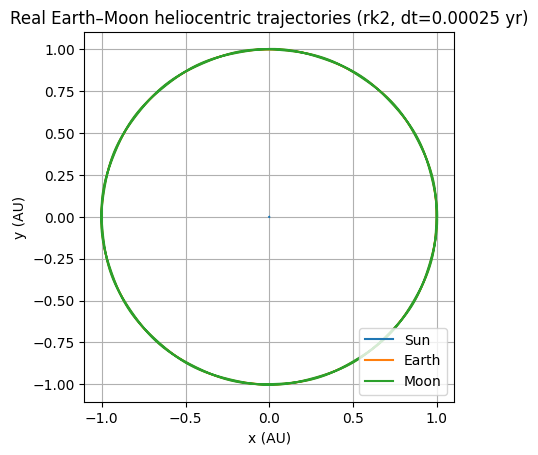

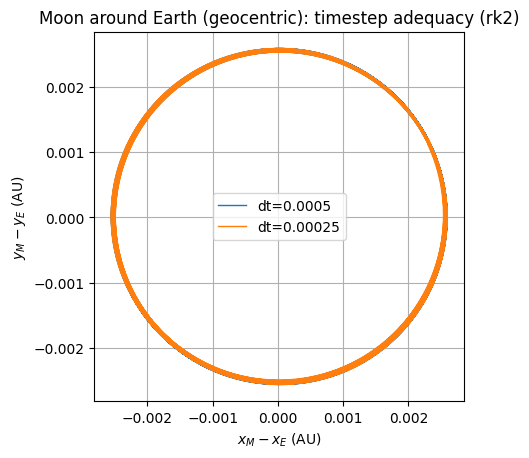

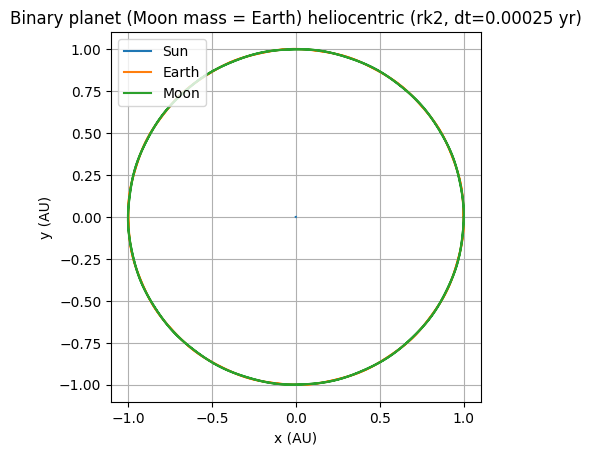

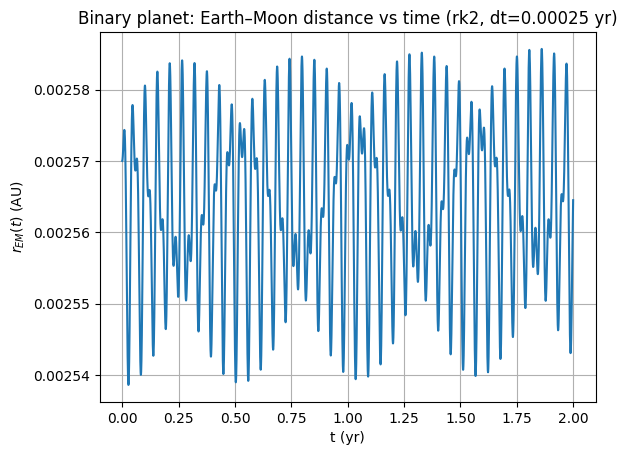

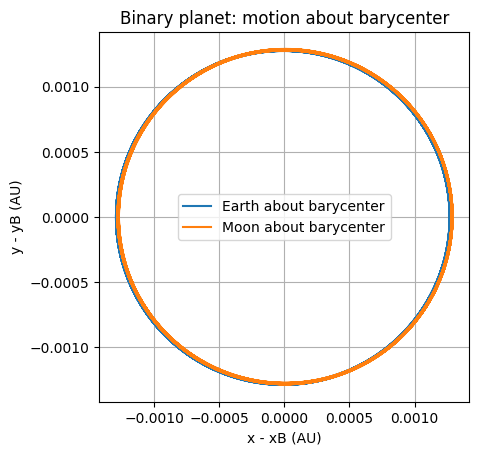

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

PI = np.pi
G  = 4.0 * PI**2

# Masses (Msun)
M_sun   = 1.0
M_earth = 3.003e-6
M_moon  = 3.694e-8

a_EM = 0.00257
T_moon = 27.321661 / 365.25
vE_circ = 2.0 * PI


def accel(positions, masses):
    N = positions.shape[0];
    a = np.zeros_like(positions, dtype = float);
    for i in range(N):
        ri = positions[i];
        for j in range(N):
            if i == j:
                continue;
            dr = positions[j] - ri;
            dist = np.hypot(dr[0], dr[1]);
            a[i] += G * masses[j] * dr / dist**3;
    return a;

def plot_barycentric(name, r, masses):
    # bodies: 0 Sun, 1 Earth, 2 Moon
    mE = masses[1];
    mM = masses[2];
    rE = r[:,1,:];
    rM = r[:,2,:];

    rB = (mE*rE + mM*rM) / (mE + mM);   # barycenter position

    plt.figure();
    plt.plot(rE[:,0]-rB[:,0], rE[:,1]-rB[:,1], label = "Earth about barycenter");
    plt.plot(rM[:,0]-rB[:,0], rM[:,1]-rB[:,1], label = "Moon about barycenter");
    plt.gca().set_aspect("equal", adjustable = "box");
    plt.xlabel("x - xB (AU)");
    plt.ylabel("y - yB (AU)");
    plt.title(name);
    plt.grid(True);
    plt.legend();
    plt.show();


def step_euler_cromer(r, v, masses, dt):
    a = accel(r, masses);
    v_new = v + a * dt;
    r_new = r + v_new * dt;
    return r_new, v_new;


def step_rk2_midpoint(r, v, masses, dt):
    a_n = accel(r, masses);
    r_mid = r + 0.5 * dt * v;
    v_mid = v + 0.5 * dt * a_n;
    a_mid = accel(r_mid, masses);
    r_new = r + dt * v_mid;
    v_new = v + dt * a_mid;
    return r_new, v_new;


def integrate_nbody(r0, v0, masses, dt, Ttot, method = "rk2"):
    n = int(Ttot / dt) + 1;
    t = np.arange(n) * dt;
    N = r0.shape[0];
    r = np.zeros((n, N, 2), dtype = float);
    v = np.zeros((n, N, 2), dtype = float);
    r[0] = r0;
    v[0] = v0;

    for k in range(n - 1):
        if method == "euler-cromer":
            r[k+1], v[k+1] = step_euler_cromer(r[k], v[k], masses, dt);
        elif method == "rk2":
            r[k+1], v[k+1] = step_rk2_midpoint(r[k], v[k], masses, dt);
        else:
            raise ValueError("method must be 'euler-cromer' or 'rk2'");

    return t, r, v;


def init_real_earth_moon(m_moon = M_moon, moon_speed_factor = 1.0):
    masses = np.array([M_sun, M_earth, float(m_moon)], dtype = float);
    rS = np.array([0.0, 0.0]); vS = np.array([0.0, 0.0]);
    rE = np.array([1.0, 0.0]); vE = np.array([0.0, vE_circ]);
    v_rel = (2.0 * PI * a_EM / T_moon) * moon_speed_factor;
    rM = rE + np.array([a_EM, 0.0]);
    vM = vE + np.array([0.0, v_rel]);
    r0 = np.vstack([rS, rE, rM]);
    v0 = np.vstack([vS, vE, vM]);

    return r0, v0, masses;


def init_binary_planet(m2 = M_earth):
    m1 = M_earth;
    m2 = float(m2);
    masses = np.array([M_sun, m1, m2], dtype = float);
    # barycenter heliocentric
    rB = np.array([1.0, 0.0]);
    vB = np.array([0.0, vE_circ]);
    mtot = m1 + m2;
    r1_rel = - (m2/mtot) * a_EM;
    r2_rel = + (m1/mtot) * a_EM;
    rE = rB + np.array([r1_rel, 0.0]);
    rM = rB + np.array([r2_rel, 0.0]);
    omega = np.sqrt(G * mtot / a_EM**3);
    vE_rel = np.array([0.0, -omega * abs(r1_rel)]);
    vM_rel = np.array([0.0, +omega * abs(r2_rel)]);
    vE = vB + vE_rel;
    vM = vB + vM_rel;
    rS = np.array([0.0, 0.0]); vS = np.array([0.0, 0.0]);
    r0 = np.vstack([rS, rE, rM]);
    v0 = np.vstack([vS, vE, vM]);

    return r0, v0, masses;


def plot_heliocentric(r, title):
    xS, yS = r[:,0,0], r[:,0,1]
    xE, yE = r[:,1,0], r[:,1,1]
    xM, yM = r[:,2,0], r[:,2,1]

    plt.figure()
    plt.plot(xS, yS, label="Sun")
    plt.plot(xE, yE, label="Earth")
    plt.plot(xM, yM, label="Moon")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("x (AU)")
    plt.ylabel("y (AU)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_geocentric_overlay(rA, rB, labelA, labelB, title):
    xEA, yEA = rA[:,1,0], rA[:,1,1]
    xMA, yMA = rA[:,2,0], rA[:,2,1]
    xEB, yEB = rB[:,1,0], rB[:,1,1]
    xMB, yMB = rB[:,2,0], rB[:,2,1]

    plt.figure()
    plt.plot(xMA - xEA, yMA - yEA, lw=1, label=labelA)
    plt.plot(xMB - xEB, yMB - yEB, lw=1, label=labelB)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel(r"$x_M-x_E$ (AU)")
    plt.ylabel(r"$y_M-y_E$ (AU)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_rEM(t, r, title):
    xE, yE = r[:,1,0], r[:,1,1]
    xM, yM = r[:,2,0], r[:,2,1]
    rEM = np.hypot(xM - xE, yM - yE)

    plt.figure()
    plt.plot(t, rEM)
    plt.xlabel("t (yr)")
    plt.ylabel(r"$r_{EM}(t)$ (AU)")
    plt.title(title)
    plt.grid(True)
    plt.show()

    return rEM


# -----------------------------
# MAIN (ONLY A FEW PLOTS)
# -----------------------------
if __name__ == "__main__":

    method = "rk2"          # or "euler-cromer"
    Ttot = 2.0

    dt  = 5e-4
    dt2 = dt / 2.0

    # --- Real Earth–Moon at dt and dt/2 ---
    r0, v0, masses = init_real_earth_moon(m_moon=M_moon, moon_speed_factor=1.0)

    t1, r1, v1 = integrate_nbody(r0, v0, masses, dt,  Ttot, method=method)
    t2, r2, v2 = integrate_nbody(r0, v0, masses, dt2, Ttot, method=method)

    # PLOT 1: heliocentric (just once, use finer dt)
    plot_heliocentric(r2, f"Real Earth–Moon heliocentric trajectories ({method}, dt={dt2:g} yr)")

    # PLOT 2: geocentric overlay (this IS the timestep adequacy plot)
    plot_geocentric_overlay(
        r1, r2,
        labelA=f"dt={dt:g}",
        labelB=f"dt={dt2:g}",
        title=f"Moon around Earth (geocentric): timestep adequacy ({method})"
    )

    # --- Hypothetical case (choose ONE) ---
    do_binary = True
    do_elliptical = False

    if do_binary:
        r0b, v0b, masses_b = init_binary_planet(m2=M_earth)
        tb, rb, vb = integrate_nbody(r0b, v0b, masses_b, dt2, Ttot, method=method)

        # PLOT 3: binary heliocentric
        plot_heliocentric(rb, f"Binary planet (Moon mass = Earth) heliocentric ({method}, dt={dt2:g} yr)")

        # PLOT 4: optional but nice: r_EM(t) for binary
        plot_rEM(tb, rb, f"Binary planet: Earth–Moon distance vs time ({method}, dt={dt2:g} yr)")

    if do_elliptical:
        r0e, v0e, masses_e = init_real_earth_moon(m_moon=M_moon, moon_speed_factor=0.90)
        te, re, ve = integrate_nbody(r0e, v0e, masses_e, dt2, Ttot, method=method)

        plot_geocentric_overlay(
            re, re,
            labelA="elliptical case",
            labelB="",
            title=f"Elliptical Moon orbit (factor=0.90) geocentric ({method})"
        )
        plot_rEM(te, re, f"Elliptical Moon: Earth–Moon distance vs time ({method}, dt={dt2:g} yr)")

plot_barycentric("Binary planet: motion about barycenter", rb, masses_b)
